# 35-Year Intercomparison of Pettitt-Derived Melt Dates Using Spatial Maps
This section presents a 35-year (1988–2022) intercomparison between Pettitt-derived melt dates and other datasets using time-averaged spatial maps. The purpose of this analysis is to evaluate the consistency and spatial behavior of the Pettitt-based estimates across different data sources.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
import seaborn as sns
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import cartopy.feature as cfeature
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap, BoundaryNorm
import geopandas as gpd
from shapely.geometry import Point
from scipy.stats import linregress, spearmanr
from pymannkendall import original_test
import matplotlib.colors as mcolors
import cmocean
from scipy.stats import kendalltau
import matplotlib.patheffects as pe


if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data_2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")

## Create the land mask for regions north of 60°N

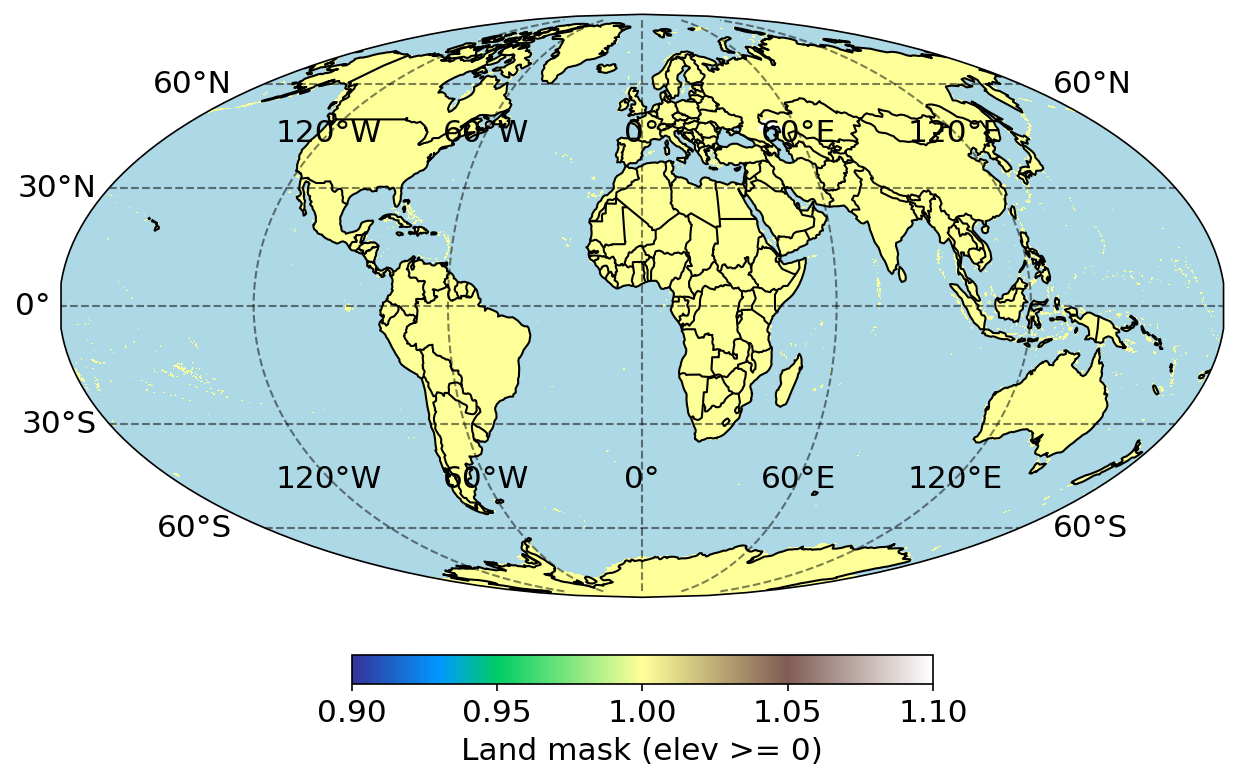

In [2]:
# Create land mask using DEM
domain_lon, domain_lat = hGrid.generate_lon_lat_eqdgrid(0.25)

DEM_path = '/home/nayoung/nas_data/DEM'
Find_DEM_File = sorted(glob.glob(os.path.join(DEM_path, "*.nc")))
DEM_25km = nc.Dataset(Find_DEM_File[0])
with nc.Dataset(Find_DEM_File[0]) as ds:
    DEM_elev = ds.variables['elev'][:]      # (lat, lon)
    lat  = ds.variables['lat'][:]       # (lat,)
    lon  = ds.variables['lon'][:]       # (lon,)

land_mask = DEM_elev > 0
land_only = np.where(land_mask, 1, np.nan)

# Check the land mask for the entire world
hPlot.plot_map(domain_lon, domain_lat, land_only, np.nanmin(land_only), 1, plot_title="Land mask (elev >= 0)", label_title="Land mask (elev >= 0)", cmap='terrain')

# Extract the pixels in the range of 60N~90N
lat_mask_idx = np.where(lat >= 60)[0]

# Cut the pixels in the range of 60N~90N
elev_np = DEM_elev.filled(np.nan)  
elev_60N = elev_np[lat_mask_idx, :]

land_mask_60N_base = np.isfinite(elev_60N).astype(np.uint8) 

## Create a function to plot the North Polar region, as the study focuses on areas north of 60°N

In [3]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = mcolors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='both',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax


## Load the cluster map and define a function for statistical summarization by cluster

In [5]:
# Load TB cluster map
cluster_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc'
with nc.Dataset(cluster_path) as ds:
    TB_cluster = np.array(ds.variables['TB_cluster'][:])  # (120, 1440)

def summarize(arr):
    if hasattr(arr, "filled"):
        arr = arr.filled(np.nan)

    arr = np.asarray(arr, dtype=np.float32)
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        return {"N": 0}
    return {
        "N": int(arr.size),
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr)),
        "median": float(np.median(arr)),
        "p05": float(np.percentile(arr, 5)),
        "p95": float(np.percentile(arr, 95)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
    }


## Figure 1. Pettitt-Derived Melt Dates
This section presents 35-year averaged spatial maps of Pettitt-derived MOD, MED, and melt duration.

In [6]:
# Define the paths and the number of years
Pettitt_MOD_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MOD_pettitt_250window_MA5_meanstd_1988_2022.nc'
Pettitt_MED_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/MED_pettitt_250window_MA5_meanstd_1988_2022.nc'
Permafrost_mask_dir = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Permafrost_waterbody_mask'
start_year, end_year = 1988, 2022
nyear = end_year - start_year + 1

# Open the file
with nc.Dataset(Pettitt_MOD_path) as ds:
    lat_vals = ds.variables['lat'][:]
    lon_vals = ds.variables['lon'][:]
    Pettitt_MOD  = ds.variables['MOD_doy'][:]   # (120, 1440, 35)

with nc.Dataset(Pettitt_MED_path) as ds:
    lat_vals = ds.variables['lat'][:]
    lon_vals = ds.variables['lon'][:]
    Pettitt_MED  = ds.variables['MED_doy'][:]   # (120, 1440, 35)

Pettitt_MOD_all = np.full((120, 1440, nyear), np.nan, dtype=np.float32)
Pettitt_MED_all = np.full((120, 1440, nyear), np.nan, dtype=np.float32)


### Table S1, Figure 1c. Pettitt MOD

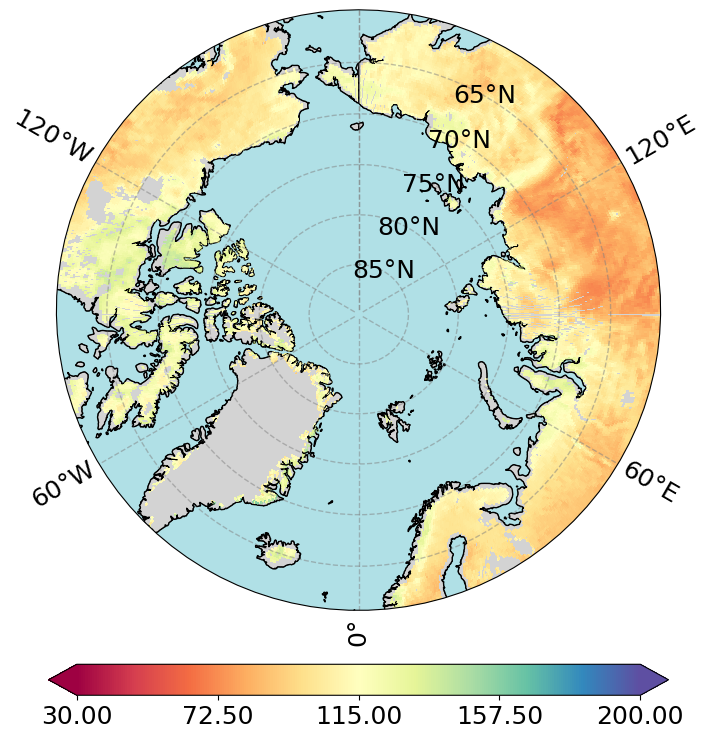

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/Pettitt_MOD_mean_1988_2022.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,40111,103.1,14.82,102.31,78.2,128.54,67.14,164.74


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,14288,97.53,12.71,96.57,77.81,121.83,67.14,164.74
1,Cluster 1,11975,116.92,10.83,117.57,98.89,133.87,74.26,145.54
2,Cluster 2,13848,96.89,11.51,99.06,76.37,113.28,70.03,129.03
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
for year in range(start_year, end_year + 1):
    yi = year - start_year

    # 1. Load yearly permafrost and waterbody mask
    mask_year = 1992 if year <= 1992 else year
    mask_file = os.path.join(Permafrost_mask_dir, f'Permafrost_waterbody_mask_25km_{mask_year}.nc') 

    with nc.Dataset(mask_file) as ds:
        snowice_mask   = ds.variables['snowice_mask'][:]
        waterbody_mask = ds.variables['water_mask'][:]  

    mask = np.isfinite(snowice_mask) & np.isfinite(waterbody_mask) & (TB_cluster != 3)  # True=valid land

    # 2. Yearly MOD 
    mod_yr  = np.array(Pettitt_MOD[:, :, yi], copy=True)

    # 3. Apply land mask
    mod_yr = np.where(mask, mod_yr, np.nan)

    Pettitt_MOD_all[:, :, yi] = mod_yr

Pettitt_MOD_all_mean = np.nanmean(Pettitt_MOD_all, axis=2)
# Exclude the cluster 3 (Just to make sure)
Pettitt_MOD_all_mean_without_c3 = np.where(TB_cluster == 3, np.nan, Pettitt_MOD_all_mean)

fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, Pettitt_MOD_all_mean_without_c3,
    None,
    'Spectral',
    vmin=30,
    vmax=200, vcenter=(30+200)/2
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "Pettitt_MOD_mean_1988_2022.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(Pettitt_MOD_all_mean_without_c3)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = Pettitt_MOD_all_mean_without_c3[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))

### Figure 1f. Violin plot of the distribution of 35-year mean MOD values across grid cells for each cluster

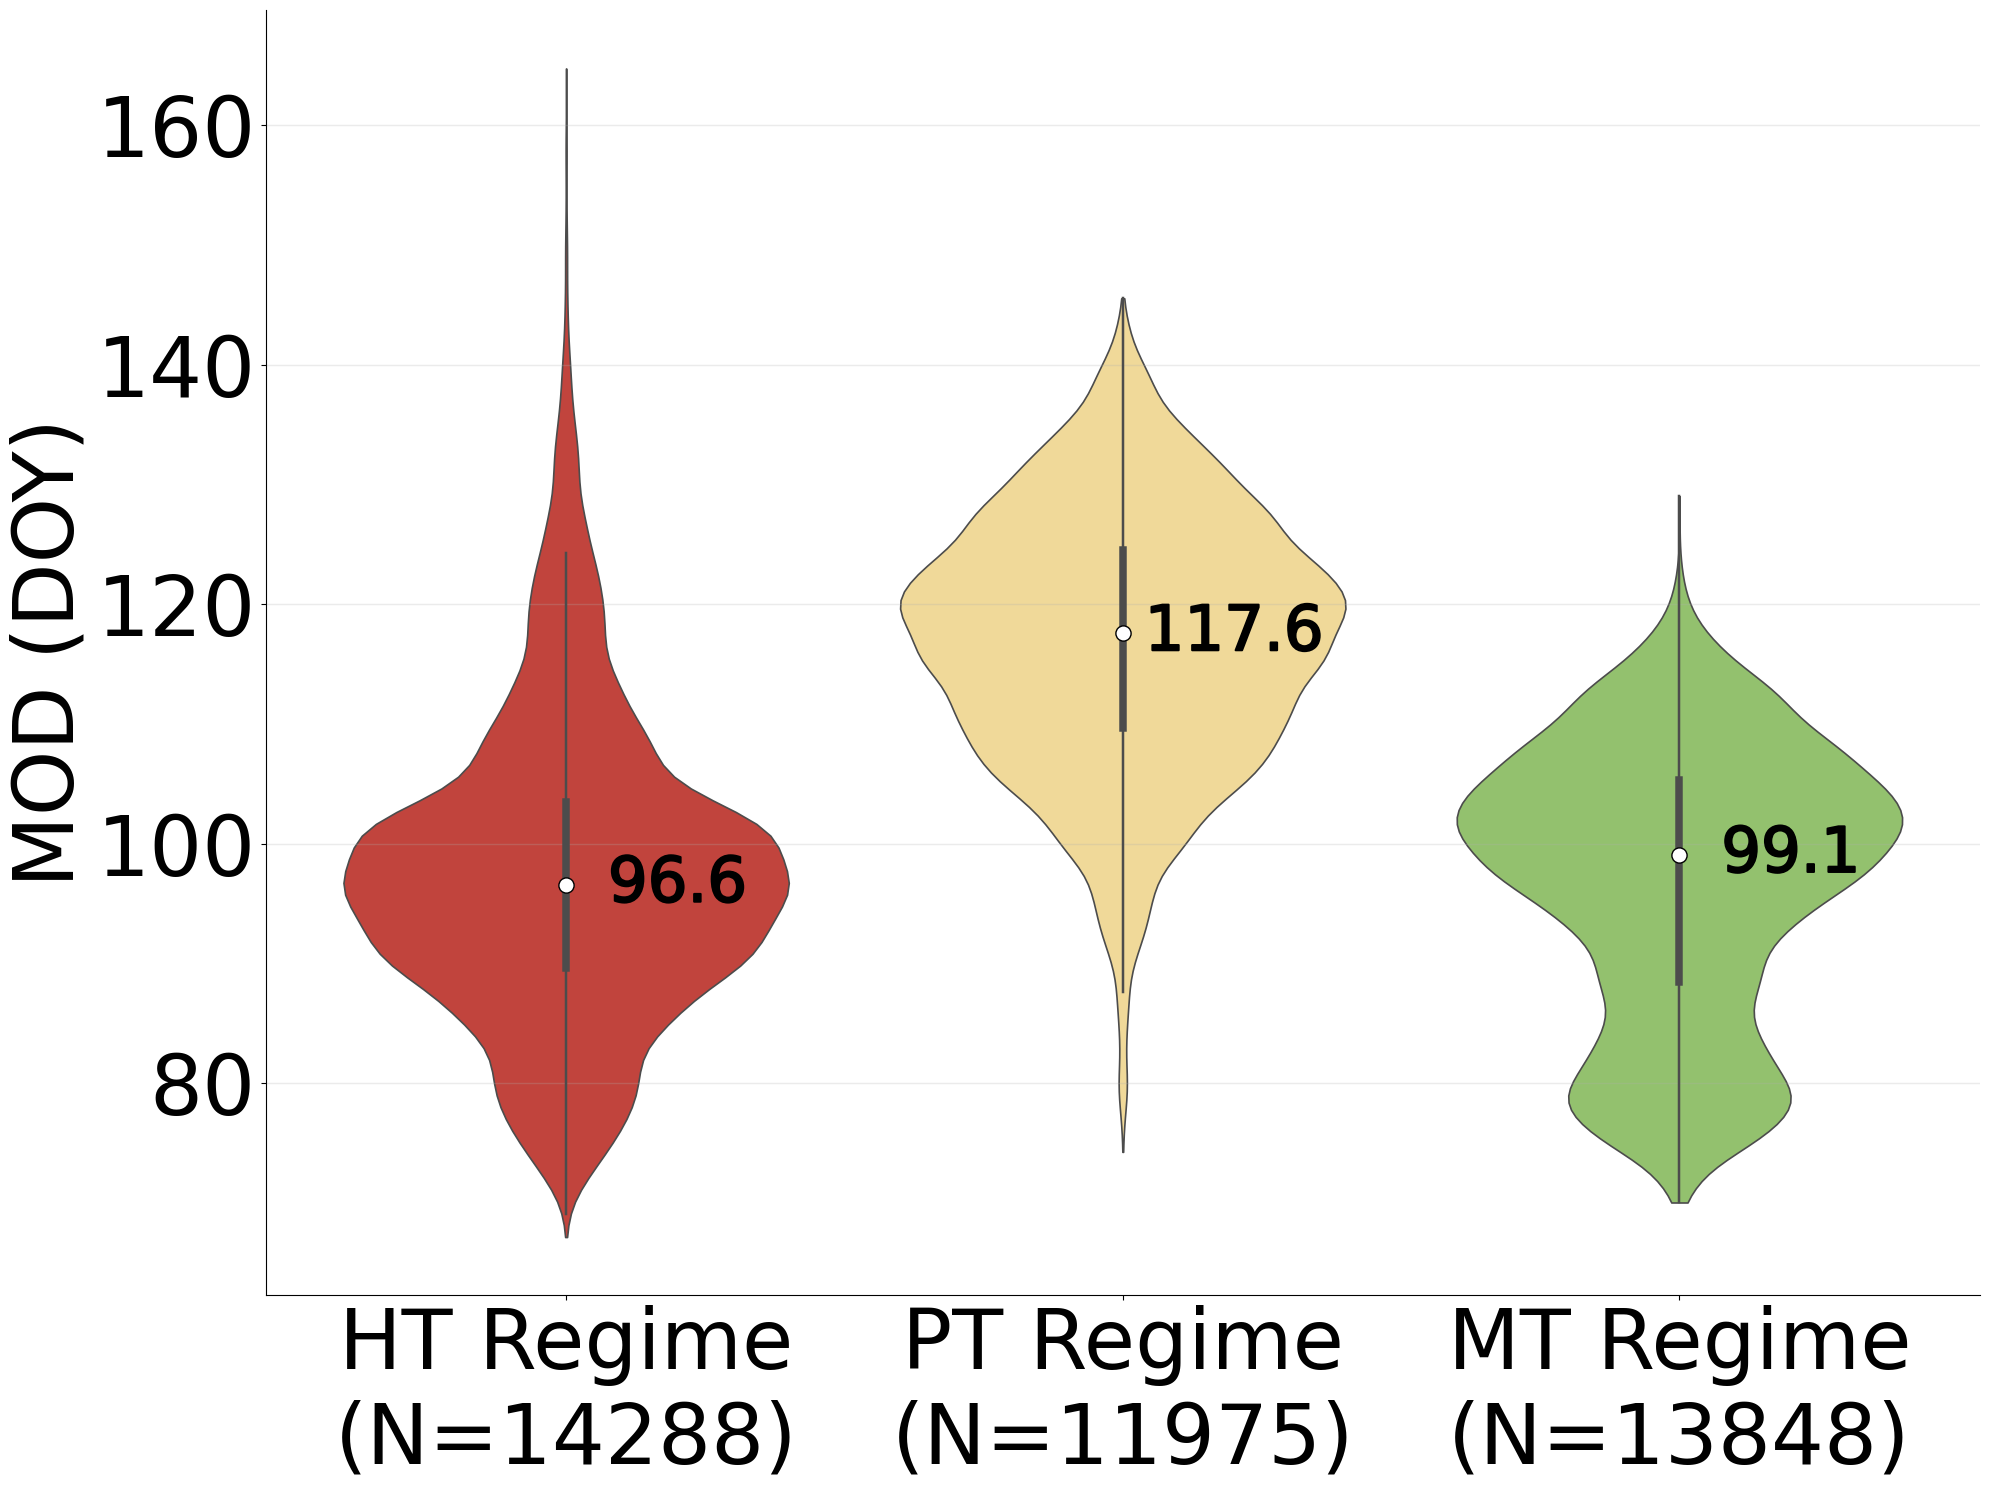

In [8]:
# Violin plot based on the statistics
rows = []

for cid in [0, 1, 2]:
    mask = (TB_cluster == cid)
    vals = Pettitt_MOD_all_mean_without_c3[mask]
    vals = vals[np.isfinite(vals)]

    for v in vals:
        rows.append({
            "Cluster": f"Cluster {cid}",
            "MOD_DOY": v
        })

df_violin = pd.DataFrame(rows)

# N counts
counts = df_violin.groupby("Cluster").size()

# Set labels
labels = [
    f"HT Regime\n(N={counts['Cluster 0']})",
    f"PT Regime\n(N={counts['Cluster 1']})",
    f"MT Regime\n(N={counts['Cluster 2']})"
]

# Set colors
palette = ["#d73027", "#fee08b", "#91cf60"]

# Plot
fig, ax = plt.subplots(figsize=(20,15))

sns.violinplot(
    data=df_violin,
    x="Cluster",
    y="MOD_DOY",
    palette=palette,
    inner="box",
    linewidth=1.2,
    cut=0,
    ax=ax
)

# Median values only
medians = df_violin.groupby("Cluster")["MOD_DOY"].median()
for i, cluster in enumerate(["Cluster 0", "Cluster 1", "Cluster 2"]):
    y = medians[cluster]

    # white median dot
    ax.scatter(
        i, y,
        color="white",
        edgecolor="black",
        s=120,
        zorder=5
    )

    # median number inside violin
    ax.text(
        i+0.2, y,
        f"{y:.1f}",
        ha="center",
        va="center",
        color="black",
        fontsize=45,
        #fontweight="bold",
        zorder=6,
        path_effects=[
            pe.withStroke(linewidth=1.5, foreground="black")
        ]
    )

ax.set_xticklabels(labels, fontsize=60)
ax.tick_params(axis='both', which='major', labelsize=60)

ax.set_ylabel("MOD (DOY)", fontsize=60)
ax.set_xlabel("")

ax.grid(axis="y", alpha=0.25)
sns.despine()

fig.tight_layout()

# Save the figure
fig.savefig(
    f"{out_dir}/Clusterwise_MOD_violinplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Table S1, Figure 1d. Pettitt MED

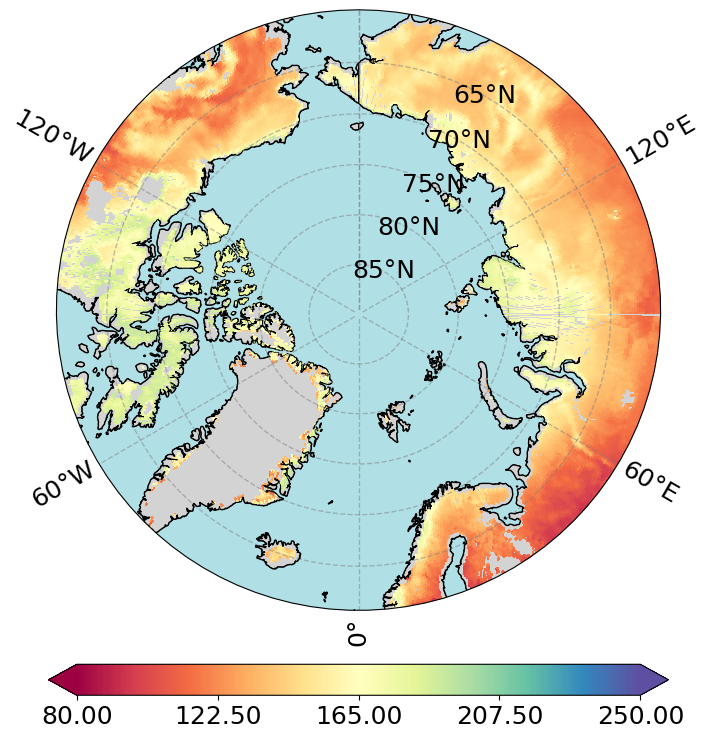

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/Pettitt_MED_mean_1988_2022.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,40111,145.32,21.5,144.31,111.87,181.56,90.49,192.97


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,14288,127.31,17.06,123.51,103.61,162.11,90.49,189.49
1,Cluster 1,11975,167.57,14.26,170.00,139.37,187.54,123.31,192.97
2,Cluster 2,13848,144.65,9.99,144.17,127.86,161.43,119.40,182.17
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
for year in range(start_year, end_year + 1):
    yi = year - start_year

    # 1. Load yearly permafrost and waterbody mask
    mask_year = 1992 if year <= 1992 else year
    mask_file = os.path.join(Permafrost_mask_dir, f'Permafrost_waterbody_mask_25km_{mask_year}.nc') 

    with nc.Dataset(mask_file) as ds:
        snowice_mask   = ds.variables['snowice_mask'][:]
        waterbody_mask = ds.variables['water_mask'][:]  

    mask = np.isfinite(snowice_mask) & np.isfinite(waterbody_mask)  # True=valid land

    # 2. Yearly MED
    med_yr  = np.array(Pettitt_MED[:, :, yi], copy=True)

    # 3. Apply land mask
    med_yr = np.where(mask, med_yr, np.nan)

    Pettitt_MED_all[:, :, yi] = med_yr

Pettitt_MED_all_mean = np.nanmean(Pettitt_MED_all, axis=2)
# Exclude the cluster 3 (Just to make sure)
Pettitt_MED_all_mean_without_c3 = np.where(TB_cluster == 3, np.nan, Pettitt_MED_all_mean)

fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, Pettitt_MED_all_mean_without_c3,
    None,
    'Spectral',
    vmin=80,
    vmax=250, vcenter=(80+250)/2
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "Pettitt_MED_mean_1988_2022.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(Pettitt_MED_all_mean_without_c3)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = Pettitt_MED_all_mean_without_c3[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))


### Figure 1g. Violin plot of the distribution of 35-year mean MED values across grid cells for each cluster

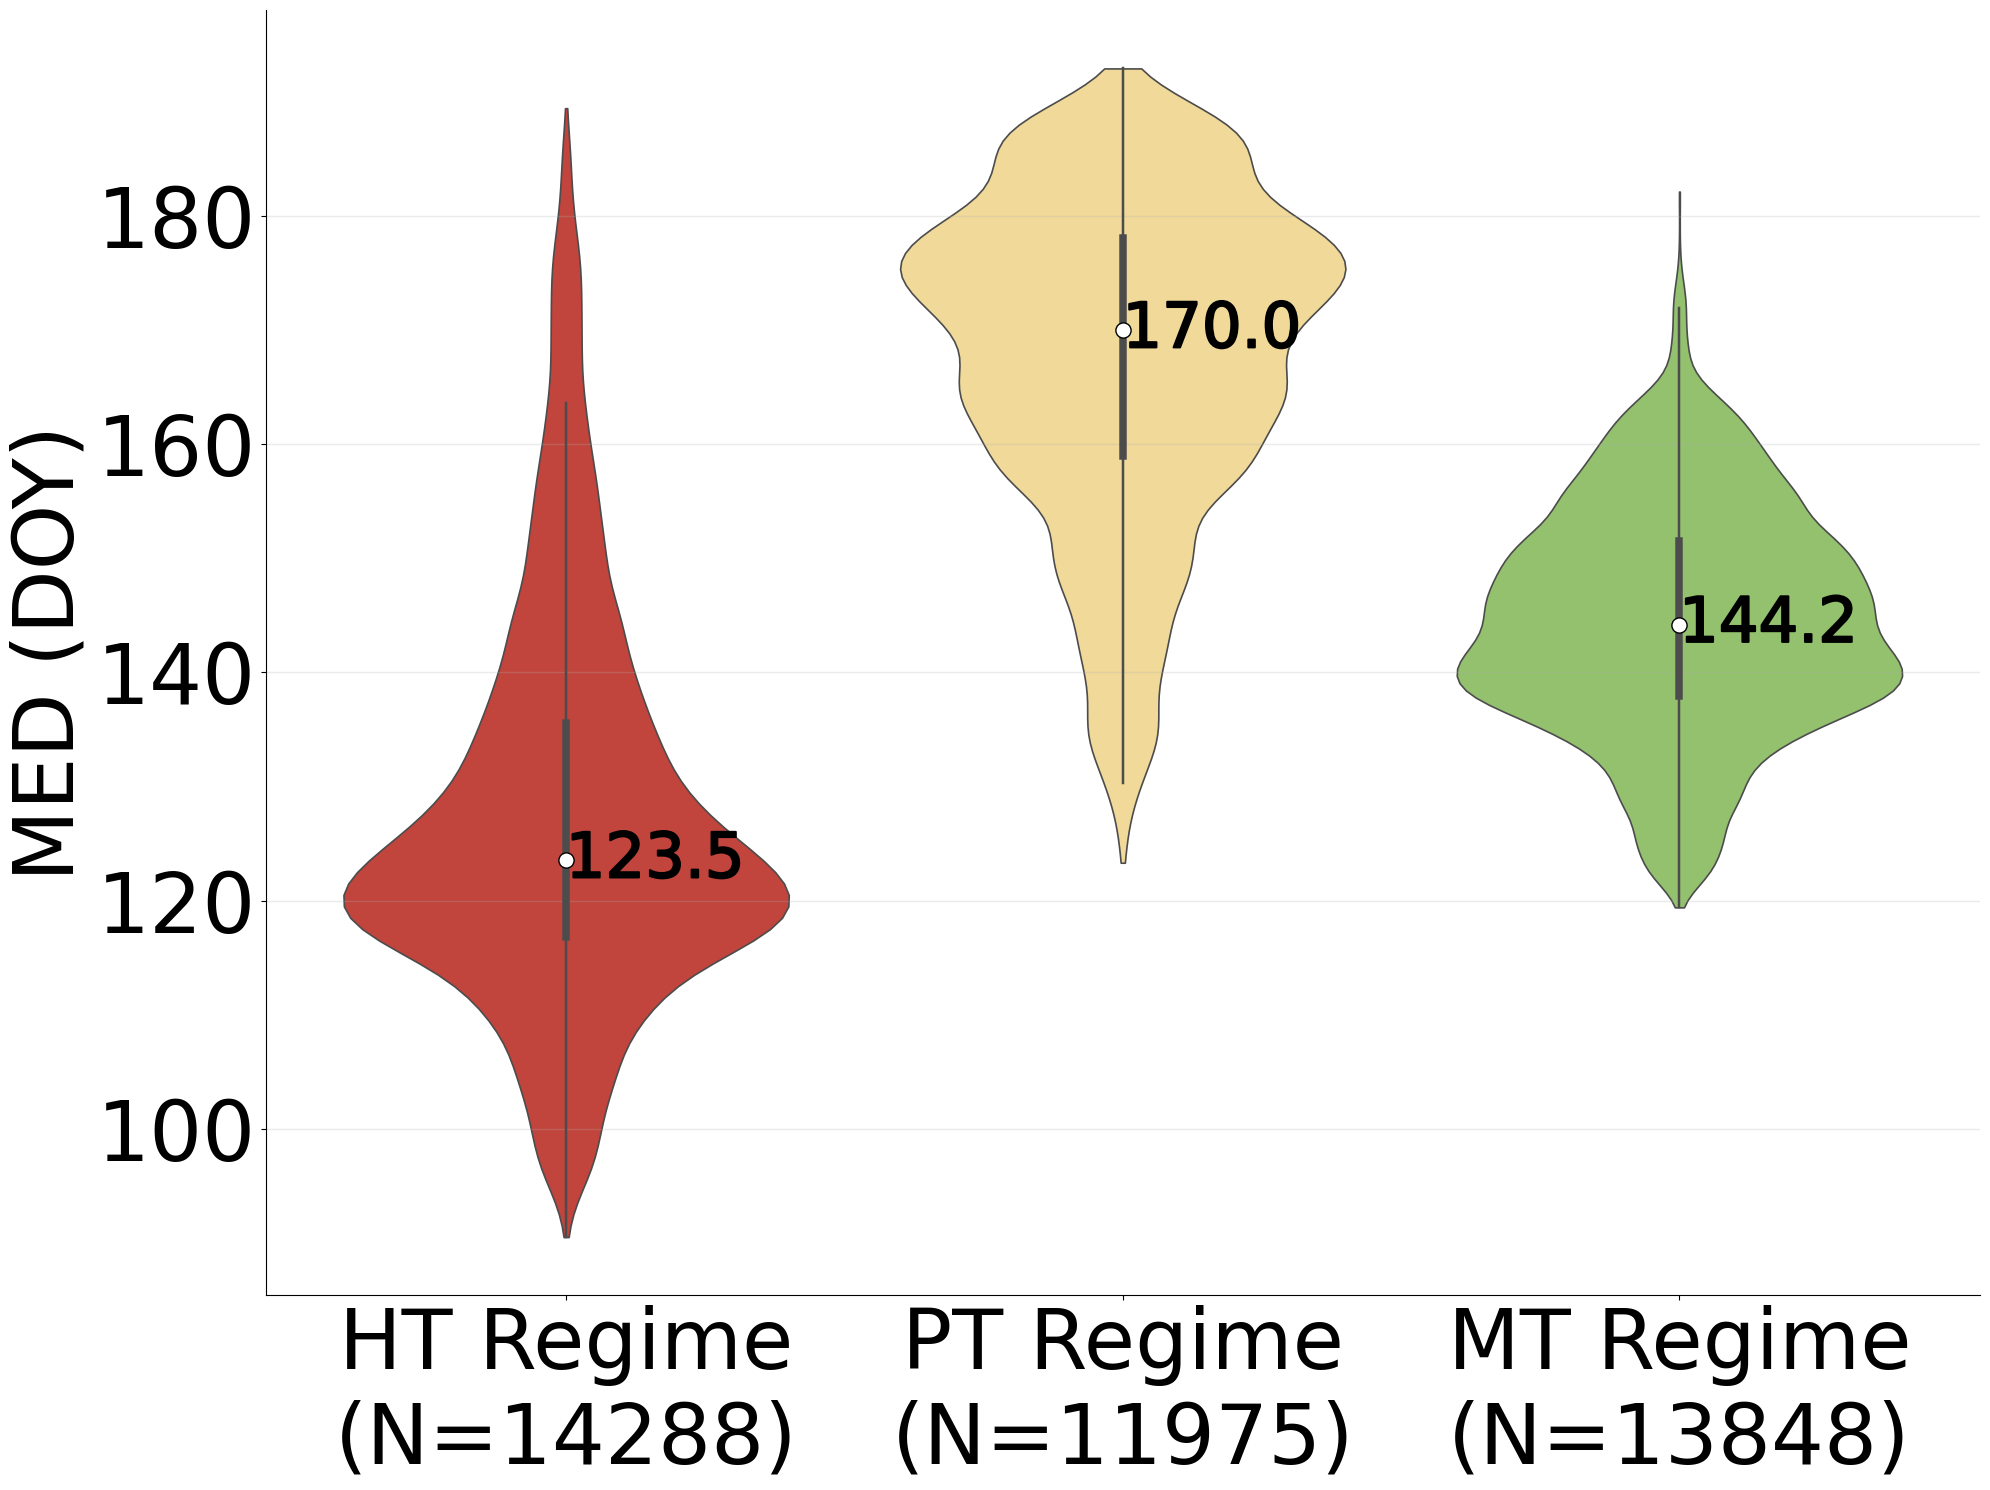

In [10]:
# Violin plot based on the statistics
rows = []

for cid in [0, 1, 2]:
    mask = (TB_cluster == cid)
    vals = Pettitt_MED_all_mean_without_c3[mask]
    vals = vals[np.isfinite(vals)]

    for v in vals:
        rows.append({
            "Cluster": f"Cluster {cid}",
            "MED_DOY": v
        })

df_violin = pd.DataFrame(rows)

# N counts
counts = df_violin.groupby("Cluster").size()

# Set labels
labels = [
    f"HT Regime\n(N={counts['Cluster 0']})",
    f"PT Regime\n(N={counts['Cluster 1']})",
    f"MT Regime\n(N={counts['Cluster 2']})"
]

# Set colors
palette = ["#d73027", "#fee08b", "#91cf60"]

# Plot
fig, ax = plt.subplots(figsize=(20,15))

sns.violinplot(
    data=df_violin,
    x="Cluster",
    y="MED_DOY",
    palette=palette,
    inner="box",
    linewidth=1.2,
    cut=0,
    ax=ax
)

# Median values only
medians = df_violin.groupby("Cluster")["MED_DOY"].median()
for i, cluster in enumerate(["Cluster 0", "Cluster 1", "Cluster 2"]):
    y = medians[cluster]

    # white median dot
    ax.scatter(
        i, y,
        color="white",
        edgecolor="black",
        s=120,
        zorder=5
    )

    # median number inside violin
    ax.text(
        i+0.16, y,
        f"{y:.1f}",
        ha="center",
        va="center",
        color="black",
        fontsize=45,
        #fontweight="bold",
        zorder=6,
        path_effects=[
            pe.withStroke(linewidth=1.5, foreground="black")
        ]
    )

ax.set_xticklabels(labels, fontsize=60)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.set_ylabel("MED (DOY)", fontsize=60)
ax.set_xlabel("")

ax.grid(axis="y", alpha=0.25)
sns.despine()

fig.tight_layout()

# Save the figure
fig.savefig(
    f"{out_dir}/Clusterwise_MED_violinplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Table S1, Figure 1e. Pettitt Melt Duration

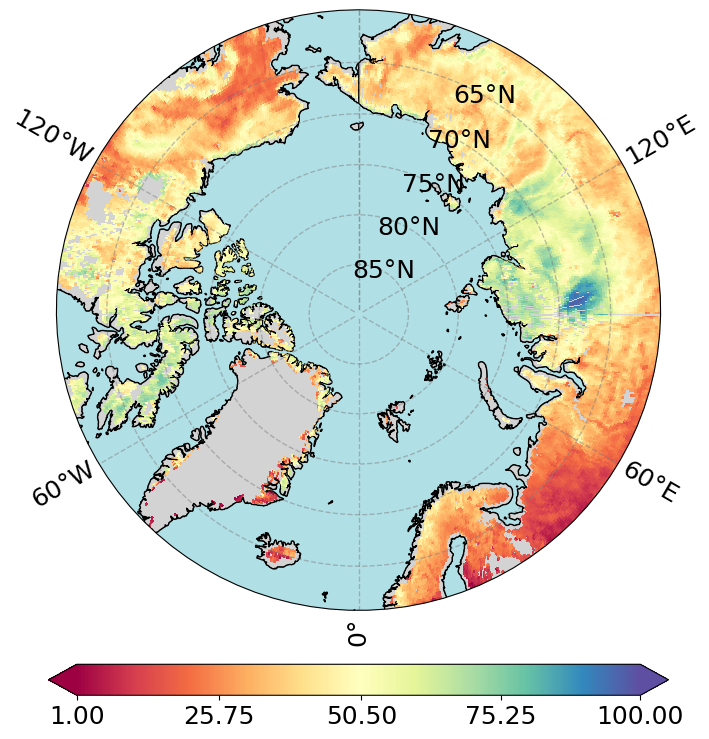

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/Pettitt_Duration_mean_1988_2022.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,40111,42.22,15.6,41.43,16.6,68.26,0.66,98.34


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,14288,29.79,11.96,29.29,10.49,49.91,0.66,75.26
1,Cluster 1,11975,50.65,12.88,50.31,29.91,71.06,16.03,98.34
2,Cluster 2,13848,47.76,12.75,45.46,30.34,70.59,18.52,97.34
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
Melt_duration = Pettitt_MED_all - Pettitt_MOD_all
Melt_duration_mean = np.nanmean(Melt_duration, axis=2)

fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, Melt_duration_mean,
    None,
    'Spectral',
    vmin=1,
    vmax=100, vcenter= int((1+100)/2)
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "Pettitt_Duration_mean_1988_2022.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(Melt_duration_mean)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = Melt_duration_mean[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))


### Figure 1h. Violin plot of the distribution of 35-year mean Melt Duration values across grid cells for each cluster

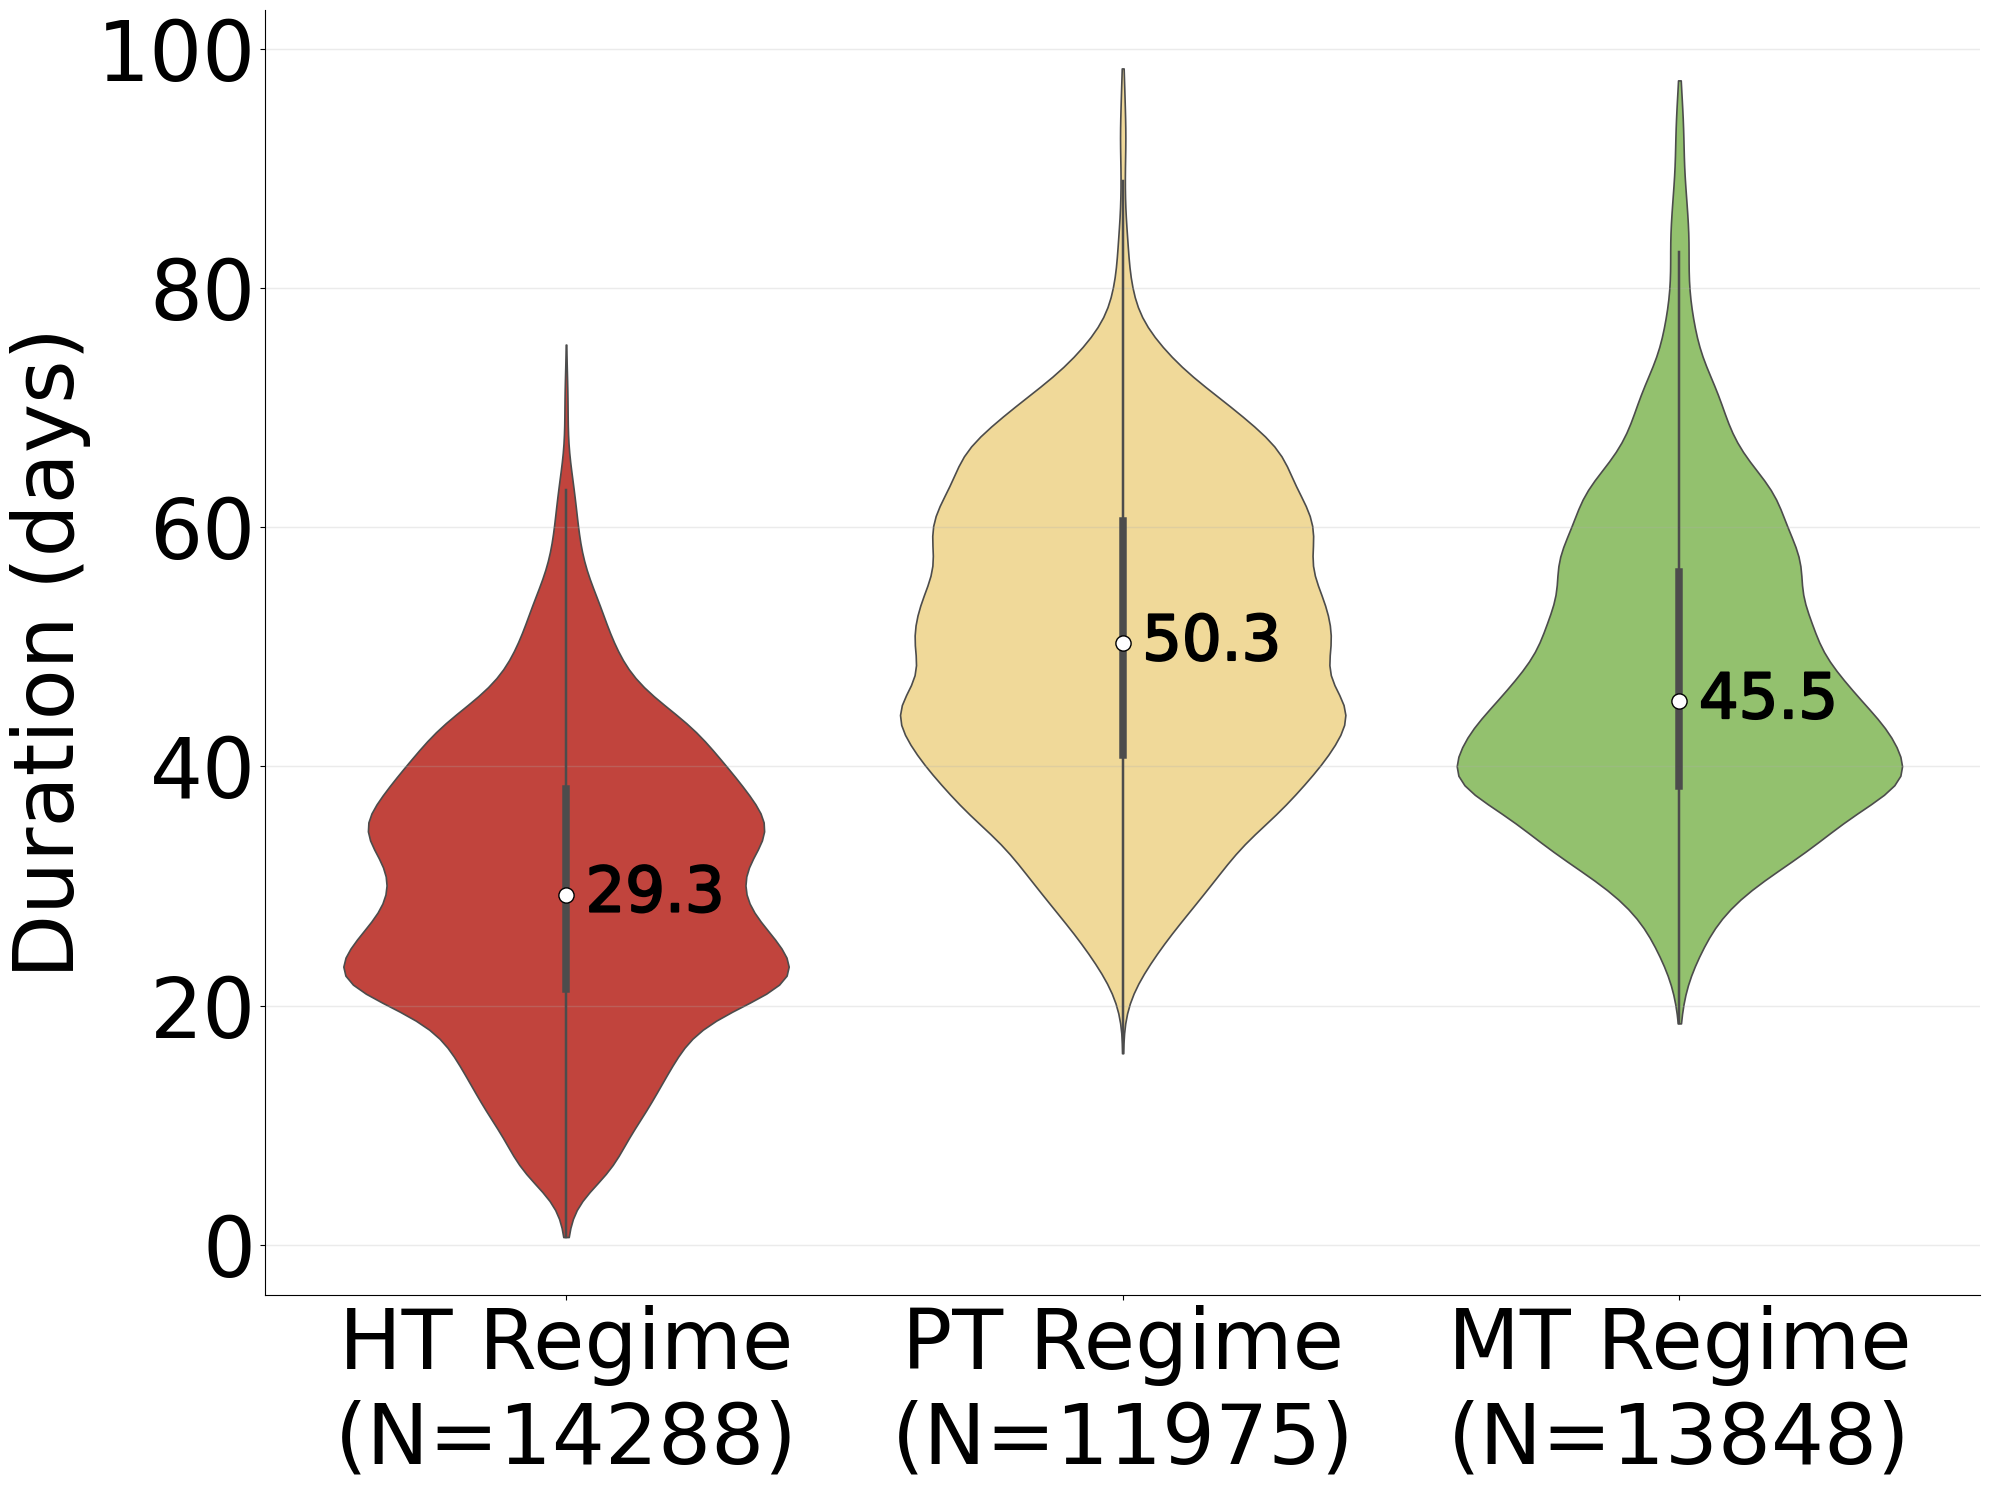

In [12]:
# Violin plot based on the statistics
rows = []

for cid in [0, 1, 2]:
    mask = (TB_cluster == cid)
    vals = Melt_duration_mean[mask]
    vals = vals[np.isfinite(vals)]

    for v in vals:
        rows.append({
            "Cluster": f"Cluster {cid}",
            "Duration_Days": v
        })

df_violin = pd.DataFrame(rows)

# N counts
counts = df_violin.groupby("Cluster").size()

# Set labels
labels = [
    f"HT Regime\n(N={counts['Cluster 0']})",
    f"PT Regime\n(N={counts['Cluster 1']})",
    f"MT Regime\n(N={counts['Cluster 2']})"
]

# Set colors
palette = ["#d73027", "#fee08b", "#91cf60"]

# Plot
fig, ax = plt.subplots(figsize=(20,15))

sns.violinplot(
    data=df_violin,
    x="Cluster",
    y="Duration_Days",
    palette=palette,
    inner="box",
    linewidth=1.2,
    cut=0,
    ax=ax
)

# Median values only
medians = df_violin.groupby("Cluster")["Duration_Days"].median()
for i, cluster in enumerate(["Cluster 0", "Cluster 1", "Cluster 2"]):
    y = medians[cluster]

    # white median dot
    ax.scatter(
        i, y,
        color="white",
        edgecolor="black",
        s=120,
        zorder=5
    )

    # median number inside violin
    ax.text(
        i+0.16, y,
        f"{y:.1f}",
        ha="center",
        va="center",
        color="black",
        fontsize=45,
        #fontweight="bold",
        zorder=6,
        path_effects=[
            pe.withStroke(linewidth=1.5, foreground="black")
        ]
    )


ax.set_xticklabels(labels, fontsize=60)
ax.tick_params(axis='both', which='major', labelsize=60)
ax.set_ylabel("Duration (days)", fontsize=60)
ax.set_xlabel("")

ax.grid(axis="y", alpha=0.25)
sns.despine()

fig.tight_layout()

# Save the figure
fig.savefig(
    f"{out_dir}/Clusterwise_Duration_violinplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## ERA5-Land-Derived Melt Dates
This section presents 35-year averaged spatial maps of ERA5-Land-derived MOD, MED, and melt duration.

In [13]:
# Define the paths and the number of years
ERA5_MOD_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/ERA5_Land/ERA5_MOD_1988_2022_north60.nc'
ERA5_MED_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/ERA5_Land/ERA5_MED_1988_2022_north60.nc'
Permafrost_mask_dir = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Permafrost_waterbody_mask'
start_year, end_year = 1988, 2022
nyear = end_year - start_year + 1

# Open the file
with nc.Dataset(ERA5_MOD_path) as ds:
    lat_vals = ds.variables['lat'][:]
    lon_vals = ds.variables['lon'][:]
    ERA5_MOD  = ds.variables['MOD_DOY'][:]   # (120, 1440, 35)

with nc.Dataset(ERA5_MED_path) as ds:
    lat_vals = ds.variables['lat'][:]
    lon_vals = ds.variables['lon'][:]
    ERA5_MED  = ds.variables['MED_DOY'][:]   # (120, 1440, 35)

ERA5_MOD_all = np.full((120, 1440, nyear), np.nan, dtype=np.float32)
ERA5_MED_all = np.full((120, 1440, nyear), np.nan, dtype=np.float32)

### 1. ERA5-Land-derived MOD

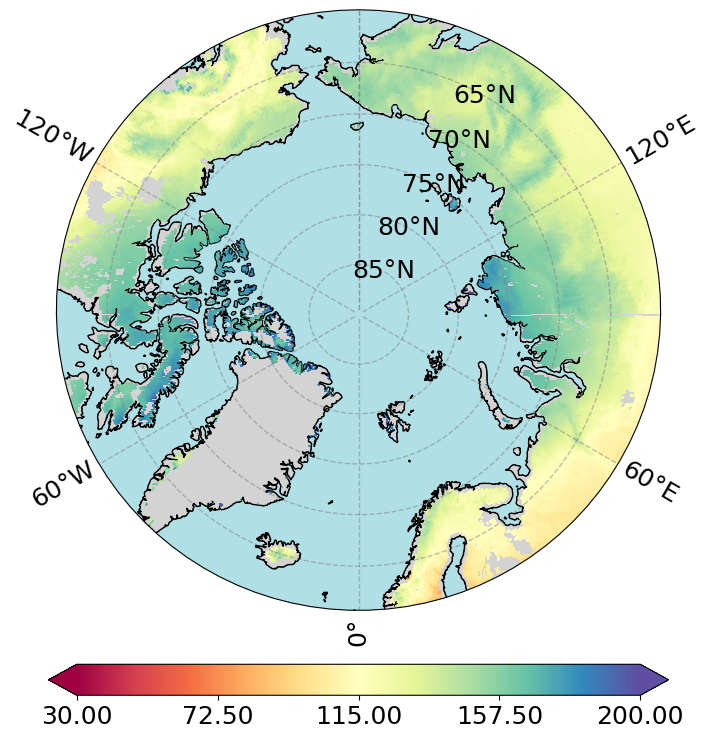

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/ERA5_MOD_mean_1988_2022.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,41031,141.16,19.95,141.77,108.51,173.69,71.68,218.5


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,13638,123.40,16.87,121.11,103.63,154.57,71.68,218.50
1,Cluster 1,11857,156.73,14.04,158.77,129.71,176.23,112.40,201.67
2,Cluster 2,13831,142.10,10.02,142.26,125.47,157.06,110.89,197.44
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
for year in range(start_year, end_year + 1):
    yi = year - start_year

    # 1. Load yearly permafrost and waterbody mask
    mask_year = 1992 if year <= 1992 else year
    mask_file = os.path.join(Permafrost_mask_dir, f'Permafrost_waterbody_mask_25km_{mask_year}.nc') 

    with nc.Dataset(mask_file) as ds:
        snowice_mask   = ds.variables['snowice_mask'][:]
        waterbody_mask = ds.variables['water_mask'][:]  

    mask = np.isfinite(snowice_mask) & np.isfinite(waterbody_mask) & (TB_cluster != 3)  # True=valid land

    # 2. Yearly MOD 
    mod_yr  = np.array(ERA5_MOD[:, :, yi], copy=True)

    # 3. Apply land mask
    mod_yr = np.where(mask, mod_yr, np.nan)

    ## Set physically unrealistic values to NaN
    # If MOD_doy is <30 or >250, set to NaN
    mod_yr = np.where(mod_yr < 30, np.nan, mod_yr)
    mod_yr = np.where(mod_yr > 250, np.nan, mod_yr)

    # If MOD_doy is greater than MED_doy, set to NaN
    mod_yr = np.where(mod_yr > ERA5_MED_all[:, :, yi], np.nan, mod_yr)

    ERA5_MOD_all[:, :, yi] = mod_yr

ERA5_MOD_all_mean = np.nanmean(ERA5_MOD_all, axis=2)
# Exclude the cluster 3 (Just to make sure)
ERA5_MOD_all_mean_without_c3 = np.where(TB_cluster == 3, np.nan, ERA5_MOD_all_mean)

fig_map, ax_map = plot_Northpole(lon_vals, lat_vals, ERA5_MOD_all_mean_without_c3,
    None,
    'Spectral',
    vmin=30,
    vmax=200, vcenter=(30+200)/2
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "ERA5_MOD_mean_1988_2022.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(ERA5_MOD_all_mean_without_c3)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = ERA5_MOD_all_mean_without_c3[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))


### 2. ERA5-Land-derived MED

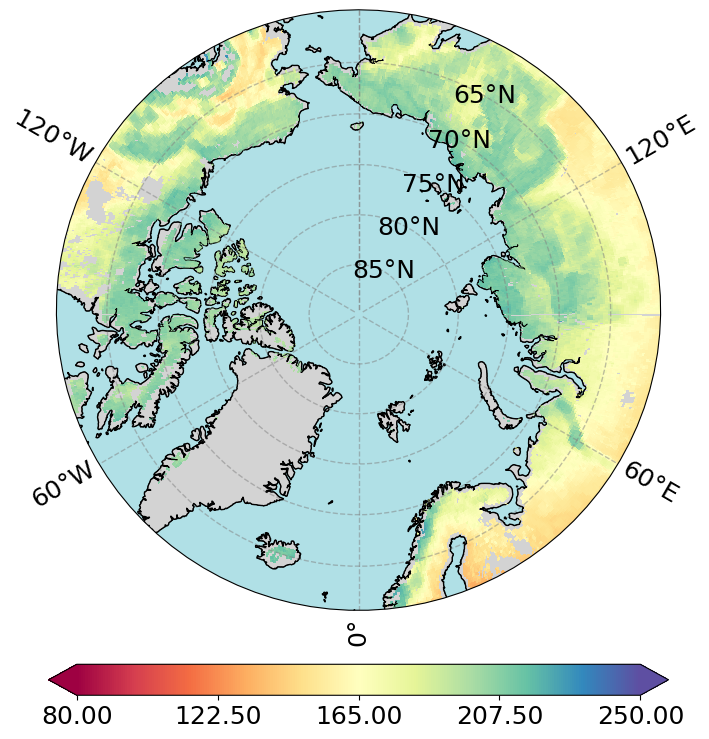

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/ERA5_MED_mean_1988_2022.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,39300,185.26,19.83,190.03,151.43,210.31,125.6,231.0


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,13070,168.08,18.26,162.94,146.47,206.36,126.86,231.00
1,Cluster 1,11303,196.09,13.80,200.09,167.55,212.03,150.40,218.94
2,Cluster 2,13690,191.39,14.31,195.37,162.83,208.87,149.17,218.94
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
for year in range(start_year, end_year + 1):
    yi = year - start_year

    # 1. Load yearly permafrost and waterbody mask
    mask_year = 1992 if year <= 1992 else year
    mask_file = os.path.join(Permafrost_mask_dir, f'Permafrost_waterbody_mask_25km_{mask_year}.nc') 

    with nc.Dataset(mask_file) as ds:
        snowice_mask   = ds.variables['snowice_mask'][:]
        waterbody_mask = ds.variables['water_mask'][:]  

    mask = np.isfinite(snowice_mask) & np.isfinite(waterbody_mask) & (TB_cluster != 3)  # True=valid land

    # 2. Yearly MED 
    med_yr  = np.array(ERA5_MED[:, :, yi], copy=True)

    # 3. Apply land mask
    med_yr = np.where(mask, med_yr, np.nan)

    ERA5_MED_all[:, :, yi] = med_yr

ERA5_MED_all_mean = np.nanmean(ERA5_MED_all, axis=2)
ERA5_MED_all_mean_without_c3 = np.where(TB_cluster == 3, np.nan, ERA5_MED_all_mean)

fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, ERA5_MED_all_mean_without_c3,
    None,
    'Spectral',
    vmin=80,
    vmax=250, vcenter=(80+250)/2
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "ERA5_MED_mean_1988_2022.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(ERA5_MED_all_mean_without_c3)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = ERA5_MED_all_mean_without_c3[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))


### 3. ERA5-Land-derived Melt Duration

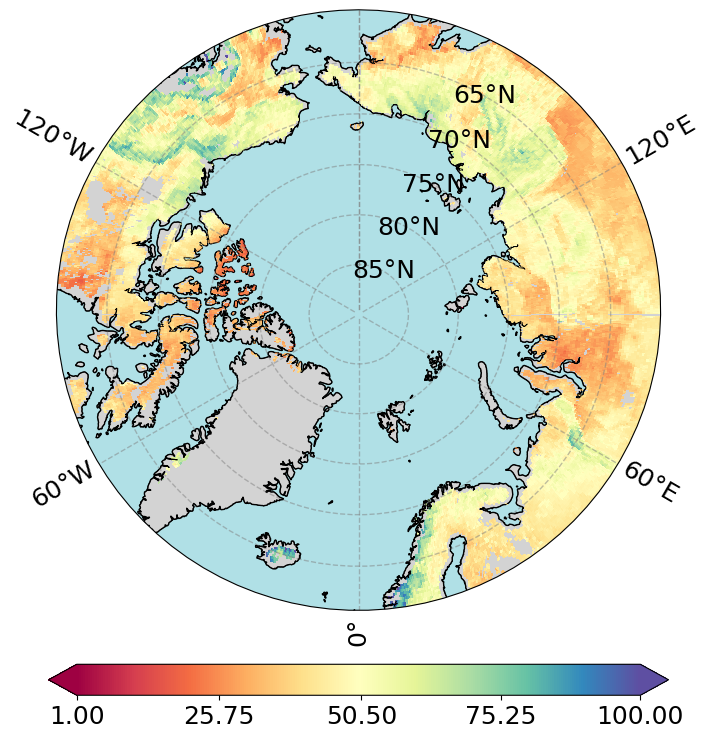

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/ERA5_Duration_mean_1988_2022.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,39300,45.79,11.26,44.89,29.37,65.46,4.0,109.5


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,13070,46.72,11.60,44.77,31.34,70.60,4.0,109.50
1,Cluster 1,11303,40.76,9.81,39.91,26.00,58.94,15.0,82.14
2,Cluster 2,13690,49.71,10.25,49.83,32.23,66.15,9.5,86.00
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
ERA5_Duration_all_without_c3 = ERA5_MED_all - ERA5_MOD_all

# Check if ERA5_MED_all is greater than ERA5_MOD_all, if not, set to NaN
ERA5_Duration_all_without_c3 = np.where(
    np.isfinite(ERA5_MOD_all) &
    np.isfinite(ERA5_MED_all) &
    (ERA5_MED_all > ERA5_MOD_all),
    ERA5_MED_all - ERA5_MOD_all,
    np.nan
)

ERA5_Duration_all_without_c3_mean = np.nanmean(ERA5_Duration_all_without_c3, axis=2)

fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, ERA5_Duration_all_without_c3_mean,
    None,
    'Spectral',
    vmin=1,
    vmax=100, vcenter=int((1+100)/2)
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "ERA5_Duration_mean_1988_2022.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)

# Statistic for the overall
s = summarize(ERA5_Duration_all_without_c3_mean)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = ERA5_Duration_all_without_c3_mean[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))


## Threshold-Based Melt Dates (Wang et al., 2013)
This section presents 35-year averaged spatial maps of MOD, MED, and melt duration derived using the threshold-based method proposed by Wang et al. (2013).

In [17]:
# Define the paths and the number of years
Threshold_MOD_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/Threshold_MOD_by_year.nc'
Threshold_MED_path = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/MOD_MED/Threshold_MED_by_year.nc'
Permafrost_mask_dir = f'{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/Permafrost_waterbody_mask'
start_year, end_year = 1988, 2022
nyear = end_year - start_year + 1

# Open the file
with nc.Dataset(Threshold_MOD_path) as ds:
    lat_vals = ds.variables['lat'][:]
    lon_vals = ds.variables['lon'][:]
    Threshold_MOD  = ds.variables['MOD_doy'][:]   # (120, 1440, 35)

with nc.Dataset(Threshold_MED_path) as ds:
    lat_vals = ds.variables['lat'][:]
    lon_vals = ds.variables['lon'][:]
    Threshold_MED  = ds.variables['MED_doy'][:]   # (120, 1440, 35)

Threshold_MOD_all = np.full((120, 1440, nyear), np.nan, dtype=np.float32)
Threshold_MED_all = np.full((120, 1440, nyear), np.nan, dtype=np.float32)


### 1. Threshold-Method-Derived MOD

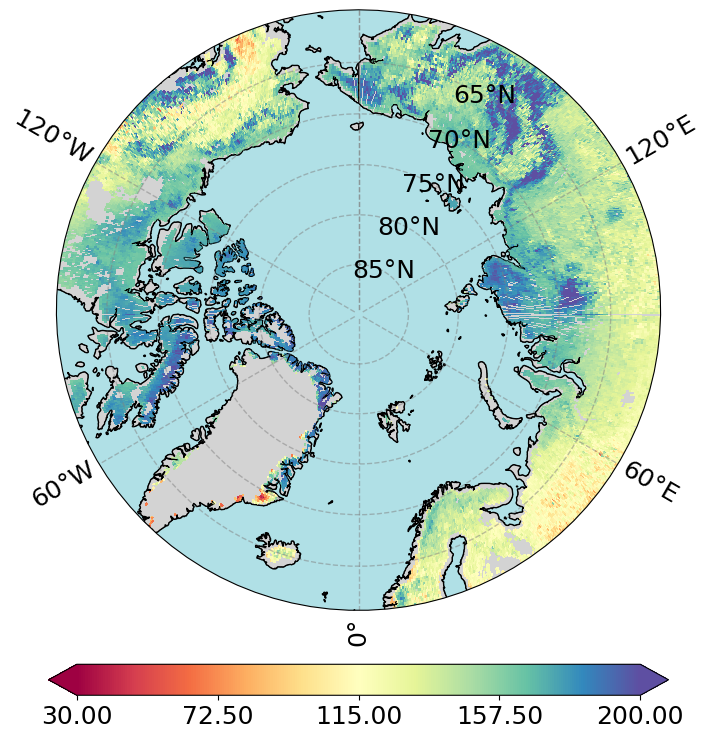

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/Wang_MOD_mean_1988_2022.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,39868,152.63,24.16,153.0,113.32,189.84,34.67,250.0


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,14226,134.77,22.93,132.00,102.59,182.93,34.67,250.0
1,Cluster 1,11917,168.25,14.03,169.49,141.09,189.63,112.00,234.0
2,Cluster 2,13725,157.58,20.34,154.50,129.81,195.70,101.33,250.0
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
for year in range(start_year, end_year + 1):
    yi = year - start_year

    # 1. Load yearly permafrost and waterbody mask
    mask_year = 1992 if year <= 1992 else year
    mask_file = os.path.join(Permafrost_mask_dir, f'Permafrost_waterbody_mask_25km_{mask_year}.nc') 

    with nc.Dataset(mask_file) as ds:
        snowice_mask   = ds.variables['snowice_mask'][:]
        waterbody_mask = ds.variables['water_mask'][:]  

    mask = np.isfinite(snowice_mask) & np.isfinite(waterbody_mask) & (TB_cluster != 3)  # True=valid land

    # 2. Yearly MOD 
    mod_yr  = np.array(Threshold_MOD[:, :, yi], copy=True)

    # 3. Apply land mask
    mod_yr = np.where(mask, mod_yr, np.nan)

    ## Set physically unrealistic values to NaN
    # If MOD_doy is <30 or >250, set to NaN
    mod_yr = np.where(mod_yr < 30, np.nan, mod_yr)
    mod_yr = np.where(mod_yr > 250, np.nan, mod_yr)

    # If MOD_doy is greater than MED_doy, set to NaN
    mod_yr = np.where(mod_yr > Threshold_MED_all[:, :, yi], np.nan, mod_yr)
    Threshold_MOD_all[:, :, yi] = mod_yr

Threshold_MOD_all_mean = np.nanmean(Threshold_MOD_all, axis=2)
Threshold_MOD_all_mean_without_c3 = np.where(TB_cluster == 3, np.nan, Threshold_MOD_all_mean)


fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, Threshold_MOD_all_mean_without_c3,
    None,
    'Spectral',
    vmin=30,
    vmax=200, vcenter=(30+200)/2
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "Wang_MOD_mean_1988_2022.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(Threshold_MOD_all_mean_without_c3)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = Threshold_MOD_all_mean_without_c3[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))


### 2. Threshold-Method-Derived MED

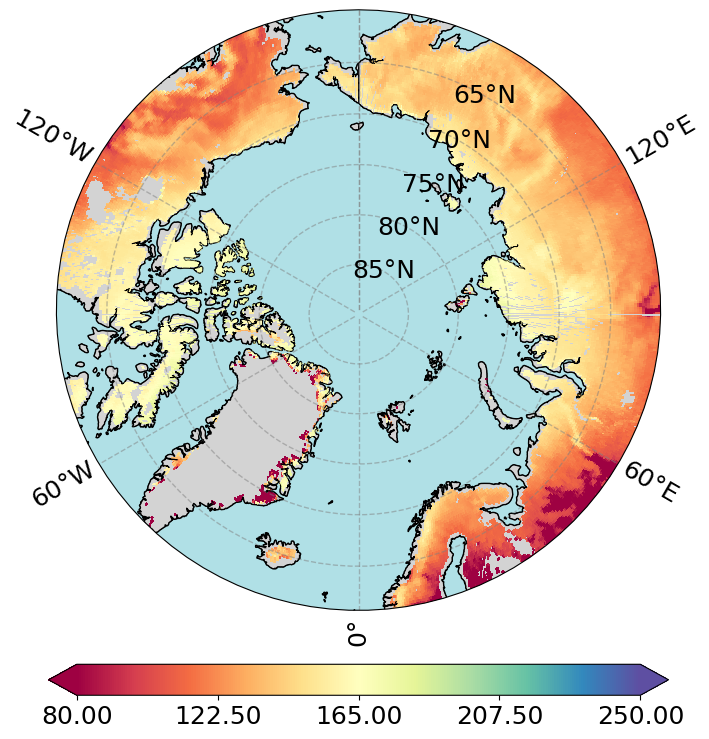

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/Wang_MED_mean_1988_2022.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,40026,135.64,23.41,138.17,98.69,167.37,2.51,190.26


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,14263,115.56,24.55,117.86,65.09,149.79,2.51,188.82
1,Cluster 1,11923,155.55,11.55,156.89,132.97,172.25,117.20,190.26
2,Cluster 2,13840,139.18,8.93,139.00,124.00,154.17,113.11,180.29
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
for year in range(start_year, end_year + 1):
    yi = year - start_year

    # 1. Load yearly permafrost and waterbody mask
    mask_year = 1992 if year <= 1992 else year
    mask_file = os.path.join(Permafrost_mask_dir, f'Permafrost_waterbody_mask_25km_{mask_year}.nc') 

    with nc.Dataset(mask_file) as ds:
        snowice_mask   = ds.variables['snowice_mask'][:]
        waterbody_mask = ds.variables['water_mask'][:]  

    mask = np.isfinite(snowice_mask) & np.isfinite(waterbody_mask) & (TB_cluster != 3)  # True=valid land

    # 2. Yearly MED 
    med_yr  = np.array(Threshold_MED[:, :, yi], copy=True)

    # 3. Apply land mask
    med_yr = np.where(mask, med_yr, np.nan)
    Threshold_MED_all[:, :, yi] = med_yr

Threshold_MED_all_mean = np.nanmean(Threshold_MED_all, axis=2)
Threshold_MED_all_mean_without_c3 = np.where(TB_cluster == 3, np.nan, Threshold_MED_all_mean)

fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, Threshold_MED_all_mean_without_c3,
    None,
    'Spectral',
    vmin=80,
    vmax=250, vcenter=(80+250)/2
)


out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "Wang_MED_mean_1988_2022.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(Threshold_MED_all_mean_without_c3)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = Threshold_MED_all_mean_without_c3[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))


### 3. Threshold-Method-Derived Melt Duration

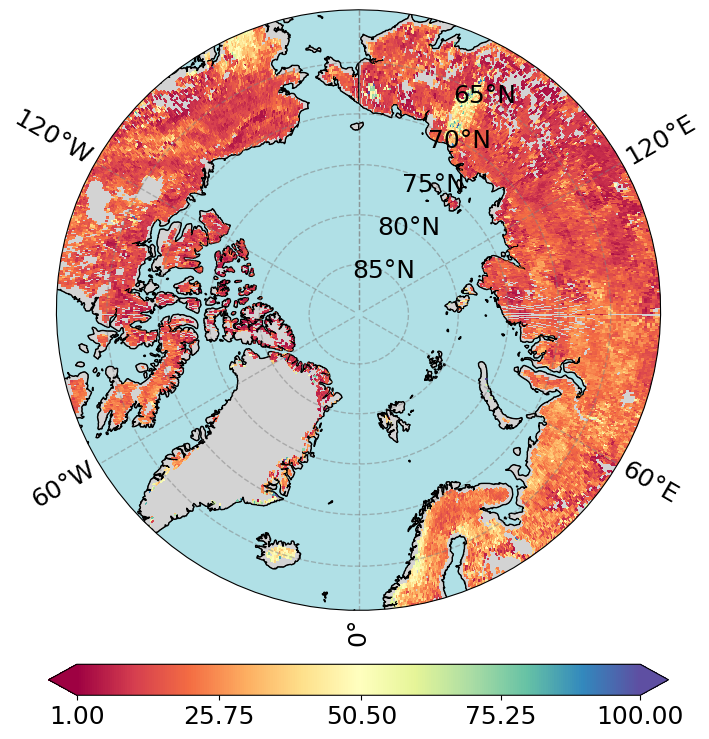

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/Wang_Duration_mean_1988_2022.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,37177,18.77,10.01,17.18,6.0,35.72,2.0,138.0


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,13357,21.51,11.74,19.8,6.80,42.41,2.0,138.0
1,Cluster 1,11474,17.89,8.39,17.0,6.33,31.00,2.0,131.0
2,Cluster 2,12346,16.62,8.59,15.4,5.75,30.00,3.0,132.0
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
Threshold_Duration_all_without_c3 = Threshold_MED_all - Threshold_MOD_all

# Check if Threshold_MED_all is greater than Threshold_MOD_all, if not, set to NaN
Threshold_Duration_all_without_c3 = np.where(
    np.isfinite(Threshold_MOD_all) &
    np.isfinite(Threshold_MED_all) &
    (Threshold_MED_all > Threshold_MOD_all),
    Threshold_MED_all - Threshold_MOD_all,
    np.nan
)
Threshold_Duration_all_without_c3_mean = np.nanmean(Threshold_Duration_all_without_c3, axis=2)

fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, Threshold_Duration_all_without_c3_mean,
    None,
    'Spectral',
    vmin=1,
    vmax=100, vcenter=int((1+100)/2)
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "Wang_Duration_mean_1988_2022.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(Threshold_Duration_all_without_c3_mean)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = Threshold_Duration_all_without_c3_mean[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))



## Figure S2a-c. Intercomparison between Pettitt-Derived and ERA5-Land-Derived Melt Dates

This section examines the differences between Pettitt-derived and ERA5-Land-derived melt dates. The difference was calculated only for pixels that satisfy all of the following conditions: (1) valid values are available for both MOD and MED from both datasets, and (2) the physical constraint of MOD < MED is satisfied for the ERA5-Land-derived estimates.

Under these conditions, the difference in Melt Dates is defined as:

`Difference_between_Pettitt_and_ERA5_MeltDates = Pettitt_MeltDates − ERA5_MeltDates`

### Figure 2a. MOD Difference

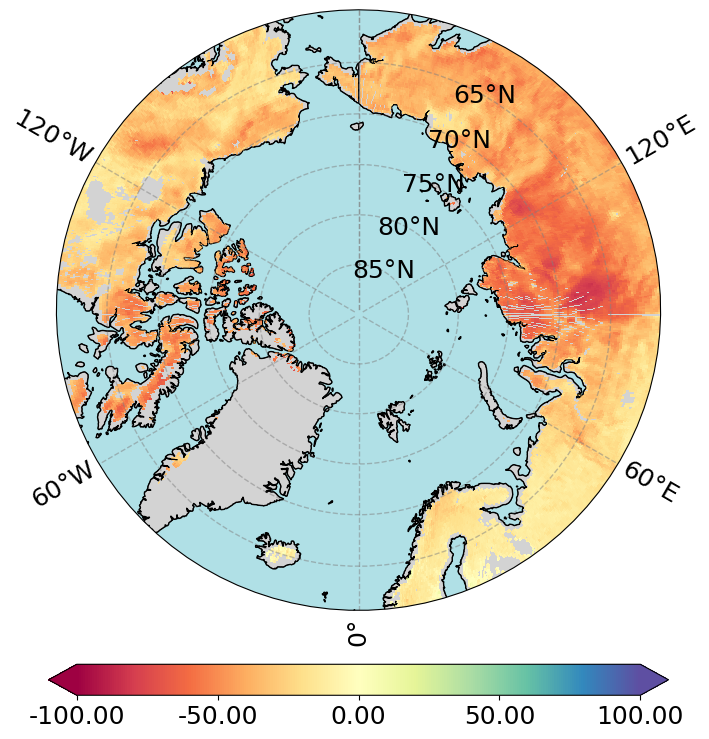

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/Difference_between_Pettitt_and_ERA5_MOD.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,38063,-36.52,15.92,-36.49,-63.32,-12.6,-85.17,41.65


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,13070,-25.76,14.01,-22.23,-50.69,-9.78,-75.46,41.65
1,Cluster 1,11303,-38.56,13.91,-36.97,-62.72,-18.17,-82.31,-6.26
2,Cluster 2,13690,-45.10,13.03,-42.91,-68.36,-25.73,-85.17,-11.17
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [21]:
Difference_between_Pettitt_and_ERA5_MOD = Pettitt_MOD_all - ERA5_MOD_all

# Set physically unrealistic values to NaN
Difference_between_Pettitt_and_ERA5_MOD = np.where(
    np.isfinite(ERA5_MOD_all) &
    np.isfinite(ERA5_MED_all) &
    np.isfinite(Pettitt_MOD_all) &
    np.isfinite(Pettitt_MED_all) &
    (ERA5_MED_all > ERA5_MOD_all),
    Pettitt_MOD_all - ERA5_MOD_all,
    np.nan
)
Difference_between_Pettitt_and_ERA5_MOD_mean = np.nanmean(Difference_between_Pettitt_and_ERA5_MOD, axis=2)

fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, Difference_between_Pettitt_and_ERA5_MOD_mean,
    None,
    'Spectral',
    vmin=-100,
    vmax=100, vcenter=int((-100+100)/2)
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "Difference_between_Pettitt_and_ERA5_MOD.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(Difference_between_Pettitt_and_ERA5_MOD_mean)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = Difference_between_Pettitt_and_ERA5_MOD_mean[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))


### Figure S2b. MED Difference

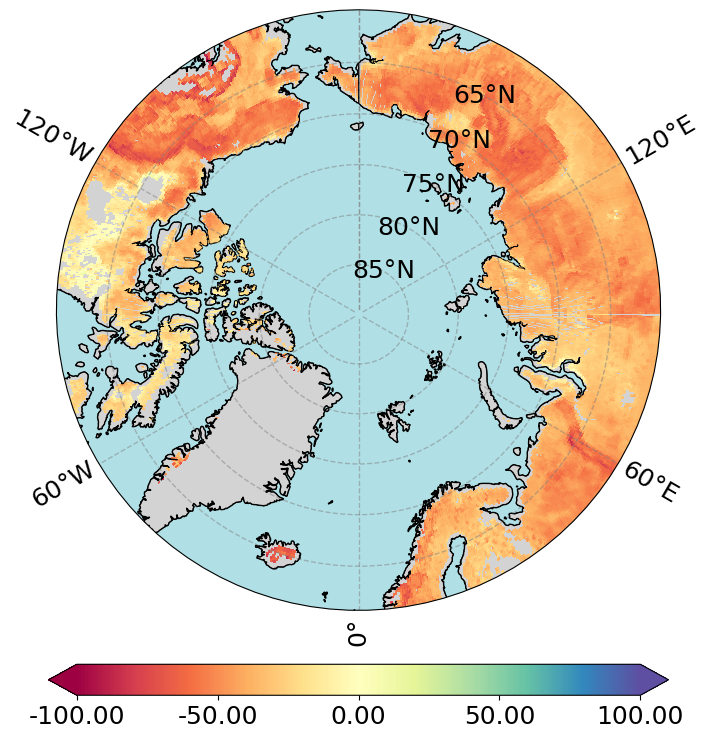

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/Difference_between_Pettitt_and_ERA5_MED.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,38063,-40.44,13.22,-40.71,-60.74,-17.51,-101.33,16.23


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,13070,-43.23,10.52,-41.66,-62.25,-28.74,-101.33,-7.00
1,Cluster 1,11303,-29.30,12.29,-29.94,-48.76,-7.32,-70.60,16.23
2,Cluster 2,13690,-46.98,10.15,-47.57,-62.97,-29.16,-80.90,2.26
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
Difference_between_Pettitt_and_ERA5_MED = Pettitt_MED_all - ERA5_MED_all

# Set physically unrealistic values to NaN
Difference_between_Pettitt_and_ERA5_MED = np.where(
    np.isfinite(ERA5_MOD_all) &
    np.isfinite(ERA5_MED_all) &
    np.isfinite(Pettitt_MOD_all) &
    np.isfinite(Pettitt_MED_all) &
    (ERA5_MED_all > ERA5_MOD_all),
    Pettitt_MED_all - ERA5_MED_all,
    np.nan
)
Difference_between_Pettitt_and_ERA5_MED_mean = np.nanmean(Difference_between_Pettitt_and_ERA5_MED, axis=2)

fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, Difference_between_Pettitt_and_ERA5_MED_mean,
    None,
    'Spectral',
    vmin=-100,
    vmax=100, vcenter=int((-100+100)/2)
)


out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "Difference_between_Pettitt_and_ERA5_MED.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(Difference_between_Pettitt_and_ERA5_MED_mean)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = Difference_between_Pettitt_and_ERA5_MED_mean[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))


### Figure S2c. Melt Duration Difference

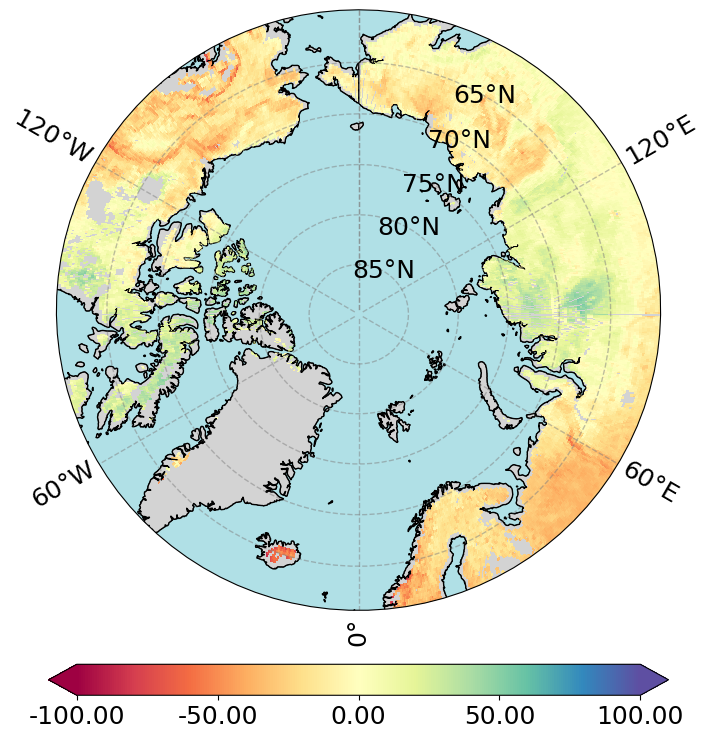

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/Difference_between_Pettitt_and_ERA5_Duration.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,38063,-3.93,19.69,-4.29,-35.06,29.04,-86.1,68.0


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,13070,-17.47,16.01,-18.67,-39.55,10.66,-86.10,68.00
1,Cluster 1,11303,9.25,16.67,9.75,-18.54,35.20,-52.69,54.43
2,Cluster 2,13690,-1.88,16.76,-1.77,-28.10,24.90,-60.52,55.54
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
Difference_between_Pettitt_and_ERA5_Duration = Melt_duration - ERA5_Duration_all_without_c3
Difference_between_Pettitt_and_ERA5_Duration_mean = np.nanmean(Difference_between_Pettitt_and_ERA5_Duration, axis=2)

fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, Difference_between_Pettitt_and_ERA5_Duration_mean,
    None,
    'Spectral',
    vmin=-100,
    vmax=100, vcenter=int((-100+100)/2)
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "Difference_between_Pettitt_and_ERA5_Duration.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(Difference_between_Pettitt_and_ERA5_Duration_mean)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = Difference_between_Pettitt_and_ERA5_Duration_mean[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))


## Figure 2d-f. Intercomparison between Pettitt-Derived and Threshold-Method-Derived Melt Dates

This section examines the differences between Pettitt-derived and Threshold-Method-derived melt dates. The difference was calculated only for pixels that satisfy all of the following conditions: (1) valid values are available for both MOD and MED from both datasets, and (2) the physical constraint of MOD < MED is satisfied for the Threshold-Method-derived estimates.

Under these conditions, the difference in Melt Dates is defined as:

`Difference_between_Pettitt_and_Threshold_MeltDates = Pettitt_MeltDates − Threshold_MeltDates`

### Figure S2d. MOD Difference

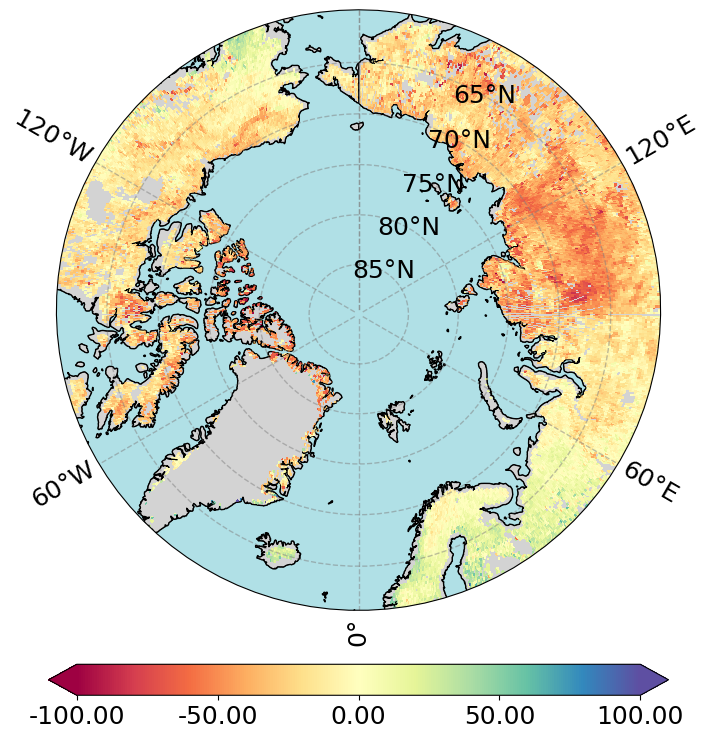

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/Difference_between_Pettitt_and_Wang_MOD.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,37177,-20.33,22.77,-20.0,-57.0,17.6,-107.0,194.0


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,13357,-5.45,22.26,-5.00,-44.00,28.90,-99.5,194.0
1,Cluster 1,11474,-25.32,19.02,-22.67,-60.53,1.83,-107.0,39.0
2,Cluster 2,12346,-31.78,17.17,-30.80,-60.50,-6.50,-107.0,17.0
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [24]:
Difference_between_Pettitt_and_Threshold_MOD = Pettitt_MOD_all - Threshold_MOD_all

# Set physically unrealistic values to NaN
Difference_between_Pettitt_and_Threshold_MOD = np.where(
    np.isfinite(Threshold_MOD_all) &
    np.isfinite(Threshold_MED_all) &
    np.isfinite(Pettitt_MOD_all) &
    np.isfinite(Pettitt_MED_all) &
    (Threshold_MED_all > Threshold_MOD_all),
    Pettitt_MOD_all - Threshold_MOD_all,
    np.nan
)
Difference_between_Pettitt_and_Threshold_MOD_mean = np.nanmean(Difference_between_Pettitt_and_Threshold_MOD, axis=2)

fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, Difference_between_Pettitt_and_Threshold_MOD_mean,
    None,
    'Spectral',
    vmin=-100,
    vmax=100, vcenter=int((-100+100)/2)
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "Difference_between_Pettitt_and_Wang_MOD.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(Difference_between_Pettitt_and_Threshold_MOD_mean)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = Difference_between_Pettitt_and_Threshold_MOD_mean[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))



### Figure S2e. MED Difference

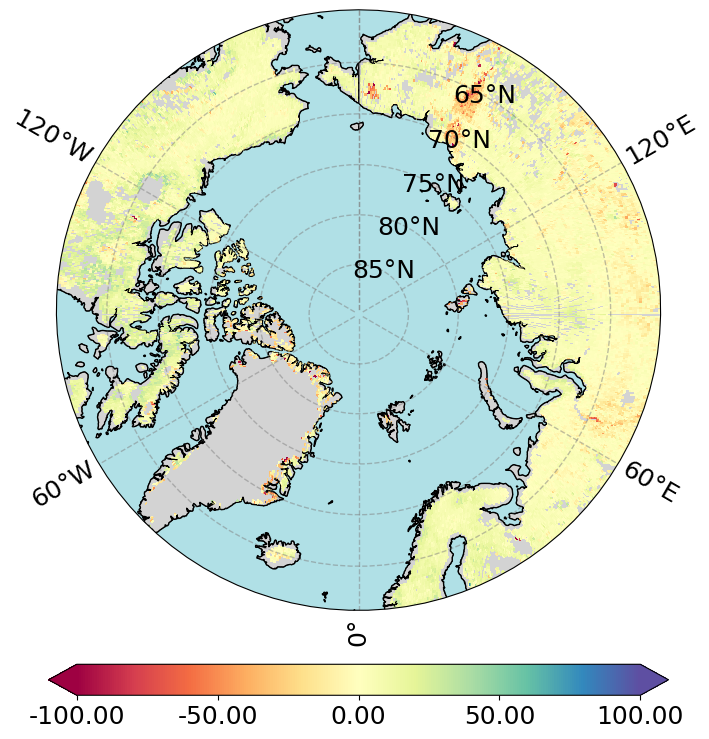

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/Difference_between_Pettitt_and_Wang_MED.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,37177,3.93,12.06,4.5,-15.0,21.6,-153.0,205.0


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,13357,2.06,12.94,3.60,-18.17,17.92,-153.0,205.00
1,Cluster 1,11474,8.07,12.27,7.61,-12.00,27.25,-110.0,44.33
2,Cluster 2,12346,2.11,9.69,3.75,-13.50,13.00,-111.0,56.00
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
Difference_between_Pettitt_and_Threshold_MED = Pettitt_MED_all - Threshold_MED_all
# Set physically unrealistic values to NaN
Difference_between_Pettitt_and_Threshold_MED = np.where(
    np.isfinite(Threshold_MOD_all) &
    np.isfinite(Threshold_MED_all) &
    np.isfinite(Pettitt_MOD_all) &
    np.isfinite(Pettitt_MED_all) &
    (Threshold_MED_all > Threshold_MOD_all),
    Pettitt_MED_all - Threshold_MED_all,
    np.nan
)
Difference_between_Pettitt_and_Threshold_MED_mean = np.nanmean(Difference_between_Pettitt_and_Threshold_MED, axis=2)

fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, Difference_between_Pettitt_and_Threshold_MED_mean,
    None,
    'Spectral',
    vmin=-100,
    vmax=100, vcenter=int((-100+100)/2)
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "Difference_between_Pettitt_and_Wang_MED.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(Difference_between_Pettitt_and_Threshold_MED_mean)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = Difference_between_Pettitt_and_Threshold_MED_mean[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))


### Figure S2f. Melt Duration Difference

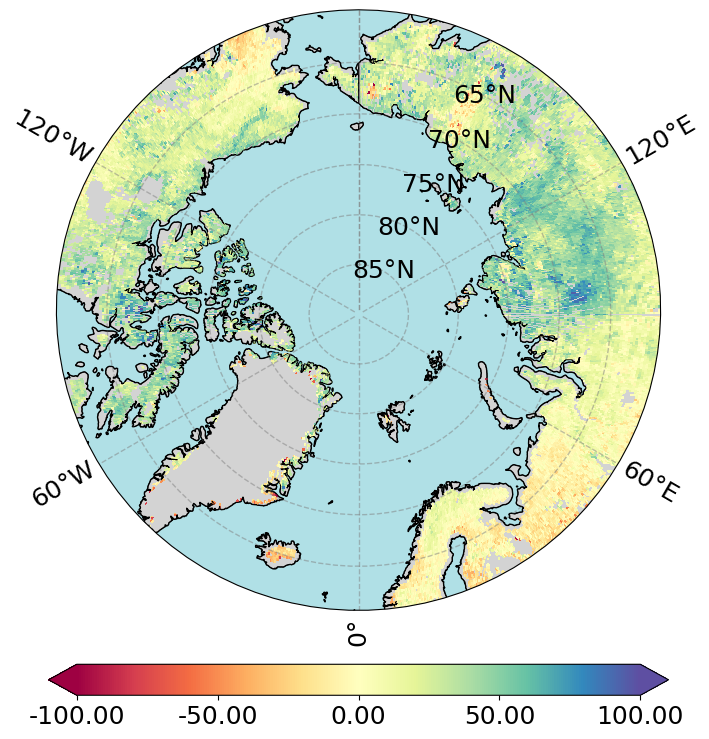

Saved: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison/Difference_between_Pettitt_and_Wang_Duration.png


,Group,N,mean,std,median,p05,p95,min,max
0,Overall,37177,24.26,22.94,25.0,-13.0,60.5,-122.6,119.0


,Cluster,N,mean,std,median,p05,p95,min,max
0,Cluster 0,13357,7.51,19.52,7.2,-22.14,38.4,-122.6,99.0
1,Cluster 1,11474,33.40,20.40,33.8,0.00,67.0,-76.0,119.0
2,Cluster 2,12346,33.89,17.68,33.6,6.50,62.0,-75.0,108.0
3,Cluster 3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
Difference_between_Pettitt_and_Threshold_Duration = Melt_duration - Threshold_Duration_all_without_c3
# Set physically unrealistic values to NaN
Difference_between_Pettitt_and_Threshold_Duration = np.where(
    np.isfinite(Threshold_MOD_all) &
    np.isfinite(Threshold_MED_all) &
    np.isfinite(Pettitt_MOD_all) &
    np.isfinite(Pettitt_MED_all) &
    (Threshold_MED_all > Threshold_MOD_all),
    Melt_duration - Threshold_Duration_all_without_c3,
    np.nan
)
Difference_between_Pettitt_and_Threshold_Duration_mean = np.nanmean(Difference_between_Pettitt_and_Threshold_Duration, axis=2)

fig_map, ax_map = plot_Northpole(
    lon_vals, lat_vals, Difference_between_Pettitt_and_Threshold_Duration_mean,
    None,
    'Spectral',
    vmin=-100,
    vmax=100, vcenter=int((-100+100)/2)
)

out_dir = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Intercomparison"
out_map = os.path.join(out_dir, "Difference_between_Pettitt_and_Wang_Duration.png")
fig_map.savefig(out_map, dpi=300, bbox_inches="tight", pad_inches=0.05)
print("Saved:", out_map)


# Statistic for the overall
s = summarize(Difference_between_Pettitt_and_Threshold_Duration_mean)
df_overall = pd.DataFrame([{
    "Group": "Overall",
    "N": s.get("N", 0),
    "mean": s.get("mean", np.nan),
    "std": s.get("std", np.nan),
    "median": s.get("median", np.nan),
    "p05": s.get("p05", np.nan),
    "p95": s.get("p95", np.nan),
    "min": s.get("min", np.nan),
    "max": s.get("max", np.nan),
}])

display(df_overall.round(2))

# Statistics for each cluster
rows = []
for cid in [0, 1, 2, 3]:
    mask_c = (TB_cluster == cid)
    vals = Difference_between_Pettitt_and_Threshold_Duration_mean[mask_c]
    s = summarize(vals)

    row = {"Cluster": f"Cluster {cid}", **s}
    rows.append(row)

df_summary = pd.DataFrame(rows)
display(df_summary.round(2))

